<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Data Mining</b></center>
<center><b><h1>Lab - 7 (Part 2)</b></center>    
<pre>

### Step 1: Load the Dataset
Load the `Tdata.csv` file and display the first few rows.

In [16]:
import pandas as pd

In [17]:
df = pd.read_csv('Tdata.csv');
print(df.head(5));

  Transaction  bread  butter  coffee  eggs  jam  milk
0          T1      1       1       0     0    0     1
1          T2      1       1       0     0    1     0
2          T3      1       0       0     1    0     1
3          T4      1       1       0     0    0     1
4          T5      1       0       1     0    0     0


### Step 2: Drop the 'Transaction' Column
We're only interested in the items (not the transaction IDs).

In [18]:
df = df.drop('Transaction', axis=1)


In [19]:
df

,bread,butter,coffee,eggs,jam,milk
0,1,1,0,0,0,1
1,1,1,0,0,1,0
2,1,0,0,1,0,1
3,1,1,0,0,0,1
4,1,0,1,0,0,0
5,0,0,1,1,1,0


### Step 3: Count Single Items
See how many transactions include each item.

In [20]:
item_count = df.sum()
print(item_count)

bread     5
butter    3
coffee    2
eggs      2
jam       2
milk      3
dtype: int64


### Step 4: Define Apriori Function
This function finds frequent itemsets of size 1, 2, and 3 with minimum support.

In [21]:
from itertools import combinations

def find_frequent_itemsets(df, min_support):
    n = len(df)
    result = []

    for k in [1,2,3]: #for 1-item, 2-item..
        for items in combinations(df.columns, k):
            mask = df[list(items)].all(axis=1)
            # print("items ",items, "mask ", mask.sum())
            support = mask.sum() / n
            if support >= min_support:
                result.append((frozenset(items), round(support, 2)))
    return result

### Step 5: Run Apriori
Set `min_support = 0.6` and display the frequent itemsets.

In [22]:
frequent_itemsets =  find_frequent_itemsets(df, min_support=0.5)

for itemset, support in frequent_itemsets:
    print(f"{set(itemset)} -> support: {support}")

{'bread'} -> support: 0.83
{'butter'} -> support: 0.5
{'milk'} -> support: 0.5
{'butter', 'bread'} -> support: 0.5
{'milk', 'bread'} -> support: 0.5


### Step 6 Display as a DataFrame

In [23]:
result_df = pd.DataFrame(frequent_itemsets, columns=["itemset", "support"])
print(result_df)

           itemset  support
0          (bread)     0.83
1         (butter)     0.50
2           (milk)     0.50
3  (butter, bread)     0.50
4    (milk, bread)     0.50


# Orange Tool : - >Generate Same Frequent Patterns in Orange tools

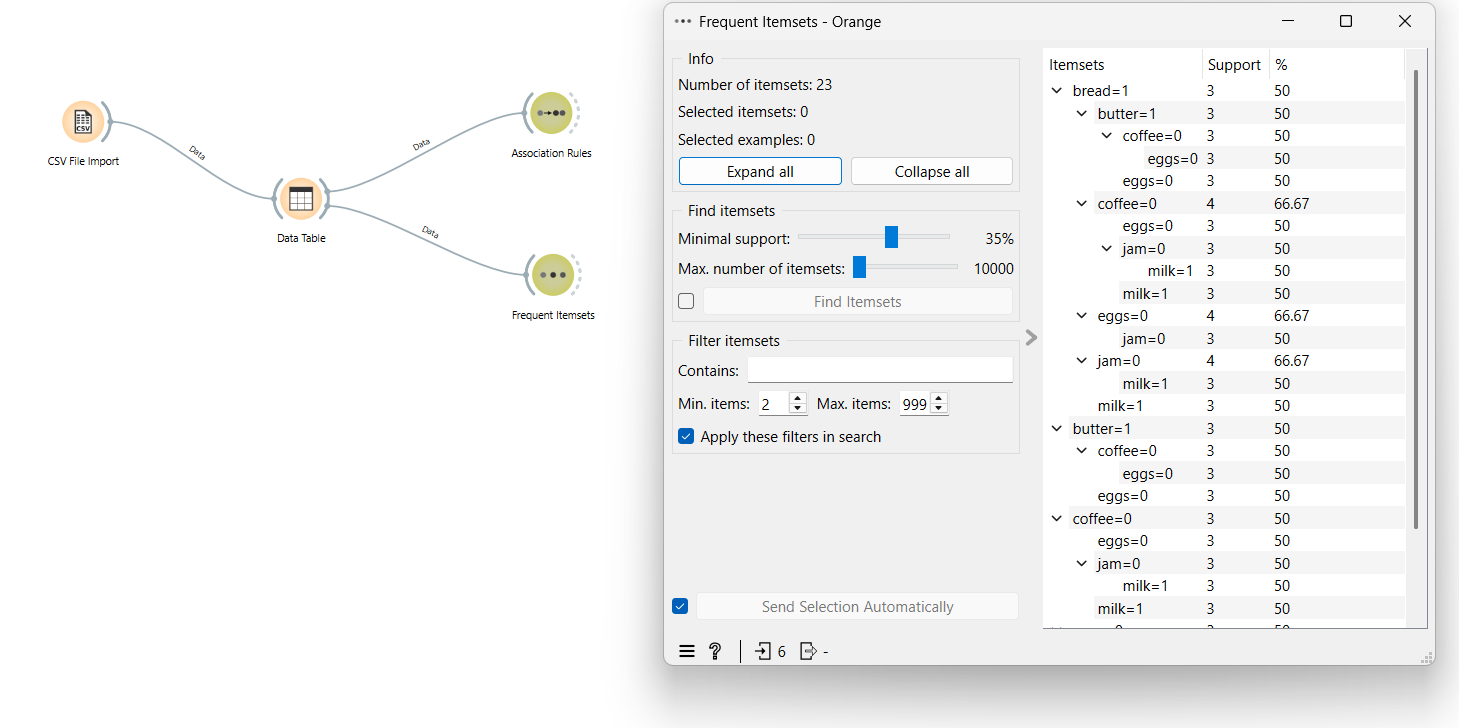

In [24]:
from IPython.display import Image
Image("C:\\Users\\pujan\\OneDrive\\Pictures\\Screenshots\\Orange SS-1.png")


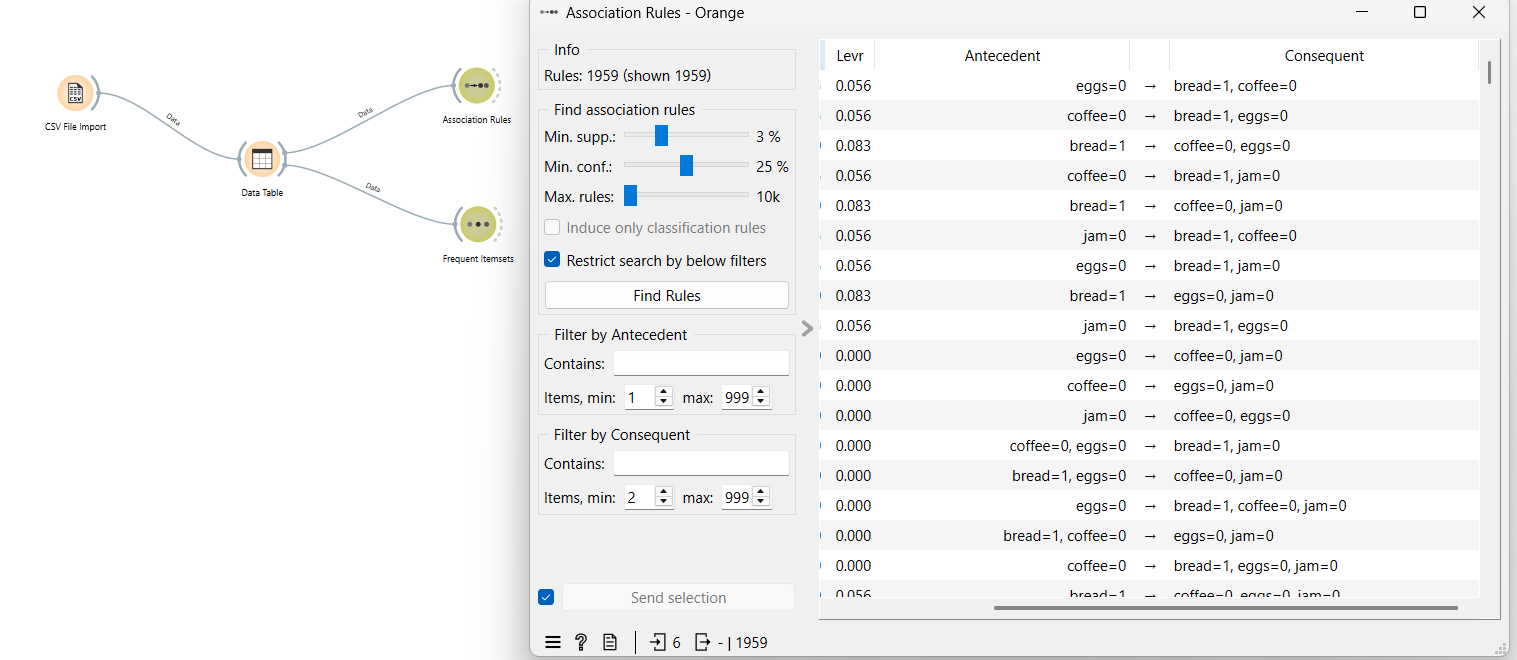

In [25]:
from IPython.display import Image
Image("C:\\Users\\pujan\\OneDrive\\Pictures\\Screenshots\\Orange SS-2.png")


# Extra : - >  Define Apriori Function without itertools

In [30]:
def generate_candidates(prev_frequent_itemsets, k):
    candidates = []
    length = len(prev_frequent_itemsets)
    for i in range(length):
        for j in range(i + 1, length):
            L1 = list(prev_frequent_itemsets[i])
            L2 = list(prev_frequent_itemsets[j])
            L1.sort()
            L2.sort()
            if L1[:k-2] == L2[:k-2]:
                new_set = set(L1) | set(L2)
                if new_set not in candidates:
                    candidates.append(new_set)
    return candidates

def apriori(dataset, min_support):
    item_counts = {}
    for transaction in dataset:
        for item in transaction:
            if item not in item_counts:
                item_counts[item] = 1
            else:
                item_counts[item] += 1

    transaction_count = len(dataset)
    frequent_itemsets = []
    L1 = []
    for item, count in item_counts.items():
        support = count / transaction_count
        if support >= min_support:
            L1.append({item})
            frequent_itemsets.append(({item}, support))

    k = 2
    current_L = L1
    while current_L:
        candidates = generate_candidates(current_L, k)
        item_counts = {frozenset(item): 0 for item in candidates}

        for transaction in dataset:
            t_set = set(transaction)
            for candidate in candidates:
                if candidate.issubset(t_set):
                    item_counts[frozenset(candidate)] += 1

        current_L = []
        for itemset, count in item_counts.items():
            support = count / transaction_count
            if support >= min_support:
                current_L.append(set(itemset))
                frequent_itemsets.append((set(itemset), support))

        k += 1

    return frequent_itemsets


In [31]:
dataset = [
    ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread'],
    ['Milk', 'Eggs'],
    ['Bread', 'Eggs'],
    ['Milk', 'Bread', 'Eggs']
]

frequent_itemsets = apriori(dataset, min_support=0.5)

for itemset, support in frequent_itemsets:
    print(f"{itemset} -> support: {support:.2f}")


{'Milk'} -> support: 0.80
{'Bread'} -> support: 0.80
{'Eggs'} -> support: 0.80
{'Milk', 'Bread'} -> support: 0.60
{'Milk', 'Eggs'} -> support: 0.60
{'Eggs', 'Bread'} -> support: 0.60
